# EDA - Análisis Exploratorio de la Oferta de StaySpain

**Equipo:** Equip_34
**Fecha:** 20/07/2026
**Dataset:** clean_dataset_13_07_2026.csv

Este notebook presenta un Análisis Exploratorio de Datos (EDA) de la oferta de alojamientos de StaySpain con el objetivo de comprender las principales características del negocio antes de compararlas con la demanda turística procedente de la Encuesta de Ocupación Hotelera (EOH).


Los resultados obtenidos permitirán posteriormente contrastar la oferta de StaySpain con indicadores oficiales de demanda turística como el origen de los viajeros, las pernoctaciones, la estacionalidad y la estancia media publicados por el INE.





## 1. Carga de datos e importación de librerías

In [160]:
# Librerías básicas para EDA
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo simple para los gráficos
sns.set_style("whitegrid")


In [180]:
# Parámetros de ejecución: actualizar solo esta sección cuando cambie el dataset
DATASET_FILE = "clean_dataset_13_07_2026.csv"
FECHA_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")


def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """Busca la carpeta raíz del proyecto desde el directorio actual."""
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' "
        f"subiendo desde {actual}"
    )


raiz_proyecto = encontrar_raiz_proyecto("Equip_34")
ruta_csv = raiz_proyecto / "Data" / DATASET_FILE

if not ruta_csv.exists():
    raise FileNotFoundError(f"No se encontró el dataset: {DATASET_FILE}")

print(f"Fecha de ejecución: {FECHA_EDA}")
print(f"Dataset: {DATASET_FILE}")

df_clean = pd.read_csv(ruta_csv)

# Columnas que deberían contener valores numéricos
columnas_numericas_esperadas = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "price_€",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month",
]

# Detección de filas con valores no numéricos en columnas numéricas
filas_inconsistentes = pd.Series(False, index=df_clean.index)

for columna in columnas_numericas_esperadas:
    valores_invalidos = (
        pd.to_numeric(df_clean[columna], errors="coerce").isna()
        & df_clean[columna].notna()
    )
    filas_inconsistentes = filas_inconsistentes | valores_invalidos

print(
    "Registros con incoherencias estructurales:",
    int(filas_inconsistentes.sum()),
)

# Se conserva el dataset original y se crea una copia válida para el EDA
df = df_clean.loc[~filas_inconsistentes].copy()

for columna in columnas_numericas_esperadas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df.head()

Fecha de ejecución: 22/07/2026
Dataset: clean_dataset_13_07_2026.csv
Registros con incoherencias estructurales: 0


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,occupancy_rate_365,is_instant_bookable_numeric,cat_premium,cat_confort,cat_conectividad,cat_familia,cat_seguridad,cat_parking,cat_cocina,logp
0,11411444,Cute apartment close to Pg.Gr�cia a,Cute apartment in Gracia! near Metro Diagonal...,14368366,la Vila de Gr�cia,Gr�cia,Entire home/apt,2,1.0,1.0,...,0.27,0,0,1,1,1,0,0,1,6.620073
1,11002274,RAMBLAS APARTMENT ONE BEDROOM,Renovated one bedroom apartment located in th...,383697,el Raval,Ciutat Vella,Entire home/apt,4,1.0,1.0,...,12.60,1,0,1,1,1,0,0,1,6.897705
2,15254167,"Zona centro, Espacio acogedor, Ambiente tranqu...",Te va a encantar mi lugar debido a el espacio ...,97013848,Hostafrancs,Sants-Montju�c,Private room,1,2.0,1.0,...,1.10,1,0,1,1,0,0,0,1,5.768321
3,16272738,Comfortable double bedroom Parc G�ell,"Cerca del Barrio de Gracia, Parc G�ell i Sagra...",13952311,el Baix Guinard�,Horta-Guinard�,Private room,2,2.0,1.0,...,1.37,1,0,1,1,1,1,0,1,6.633318
4,1198074,005596_APARTAMENTO DE 2 DORMITORIOS,!!!-ATTENTION-!!! HERE YOU HAVE THE CHANCE FOR...,6544866,la Dreta de l'Eixample,Eixample,Entire home/apt,4,2.0,2.0,...,58.36,1,0,1,1,1,1,0,1,7.600902


## 2. Visión general del dataset

In [162]:
# Dimensiones del dataset bruto y de la muestra válida para el EDA
print("Filas del dataset bruto:", df_raw.shape[0])
print("Columnas:", df_raw.shape[1])
print("Filas utilizadas en el EDA:", df.shape[0])
print(
    "Filas excluidas por incoherencias estructurales:",
    df_raw.shape[0] - df.shape[0],
)

Filas del dataset bruto: 9650
Columnas: 54
Filas utilizadas en el EDA: 9650
Filas excluidas por incoherencias estructurales: 0


La validación estructural no detecta registros con valores desalineados en las columnas numéricas esperadas. Por tanto, las 9650 observaciones del dataset bruto se mantienen en la muestra utilizada para el EDA.

Esta comprobación se conserva como control de calidad para futuras actualizaciones del dataset, sin modificar el archivo CSV original.

In [163]:
# Tipos de datos de cada columna
df.dtypes


apartment_id                     int64
name                            object
description                     object
host_id                          int64
neighbourhood_name              object
neighbourhood_district          object
room_type                       object
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities_list                  object
price_€                        float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                object
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date               object
last_review_date                object
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

Recordatorio (Data Understanding): `first_review_date`,
`last_review_date` e `insert_date` pueden llegar como texto en
formato `dd/mm/yyyy` o `yyyy-mm-dd`. Para poder explorarlas como fechas
se convierten aquí de manera temporal, sin sobrescribir el CSV
original.


In [164]:
# Conversión robusta de fechas para los formatos esperados
def convertir_fecha(serie):
    """Convierte fechas ISO o dd/mm/yyyy sin modificar el CSV original."""
    texto = serie.astype("string")
    resultado = pd.Series(pd.NaT, index=serie.index, dtype="datetime64[ns]")

    mascara_iso = texto.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)

    resultado.loc[mascara_iso] = pd.to_datetime(
        texto.loc[mascara_iso],
        format="%Y-%m-%d",
        errors="coerce",
    )
    resultado.loc[~mascara_iso] = pd.to_datetime(
        texto.loc[~mascara_iso],
        format="%d/%m/%Y",
        errors="coerce",
    )

    return resultado


for columna_fecha in [
    "first_review_date",
    "last_review_date",
    "insert_date",
]:
    df[columna_fecha] = convertir_fecha(df[columna_fecha])


In [165]:
# Número de valores nulos por columna, ordenado de mayor a menor
nulos = df.isnull().sum().sort_values(ascending=False)
nulos[nulos > 0]


neighbourhood_district         3790
review_scores_location         2640
review_scores_value            2640
review_scores_checkin          2639
review_scores_accuracy         2634
review_scores_communication    2630
review_scores_cleanliness      2628
review_scores_rating           2625
rating_above_80                2625
last_review_date               2523
reviews_per_month              2522
first_review_date              2522
has_availability                534
has_availability_numeric        534
logp                            241
price_€                         241
description                     134
bathrooms                        72
bedrooms                         70
beds                             45
amenities_list                   26
name                              3
dtype: int64

In [166]:
# Porcentaje de nulos sobre el total de filas
pct_nulos = (nulos[nulos > 0] / len(df) * 100).round(2)
pct_nulos


neighbourhood_district         39.27
review_scores_location         27.36
review_scores_value            27.36
review_scores_checkin          27.35
review_scores_accuracy         27.30
review_scores_communication    27.25
review_scores_cleanliness      27.23
review_scores_rating           27.20
rating_above_80                27.20
last_review_date               26.15
reviews_per_month              26.13
first_review_date              26.13
has_availability                5.53
has_availability_numeric        5.53
logp                            2.50
price_€                         2.50
description                     1.39
bathrooms                       0.75
bedrooms                        0.73
beds                            0.47
amenities_list                  0.27
name                            0.03
dtype: float64

`neighbourhood_district` sigue siendo la variable con mayor proporción de valores nulos. `has_availability` también presenta un bloque relevante de valores ausentes, por lo que su calidad y utilidad analítica deberán revisarse antes de utilizarla en análisis posteriores.

In [167]:
# Duplicados: filas 100% idénticas
duplicados_totales = df.duplicated().sum()
print("Filas totalmente duplicadas:", duplicados_totales)

# Duplicados por apartment_id (mismo alojamiento, otra fila)
duplicados_id = df["apartment_id"].duplicated().sum()
print("apartment_id duplicados:", duplicados_id)


Filas totalmente duplicadas: 0
apartment_id duplicados: 0


## 3. Distribuciones y boxplots de variables representativas

In [168]:
#Porcentaje de oferta

porcentaje = (
    alojamientos_ciudad.copy()
)

porcentaje["porcentaje"] = (
    porcentaje["alojamientos"]
    / porcentaje["alojamientos"].sum()
    *100
).round(2)

display(porcentaje)

,city,alojamientos,porcentaje
0,barcelona,2719,28.18
1,madrid,2134,22.11
2,mallorca,1583,16.40
3,girona,1485,15.39
4,valencia,513,5.32
5,malaga,504,5.22
6,sevilla,494,5.12
7,menorca,218,2.26


## 4. Características de la oferta

En esta sección se analizan las principales características de los alojamientos ofrecidos por StaySpain, incluyendo su capacidad, disponibilidad y nivel de precios.

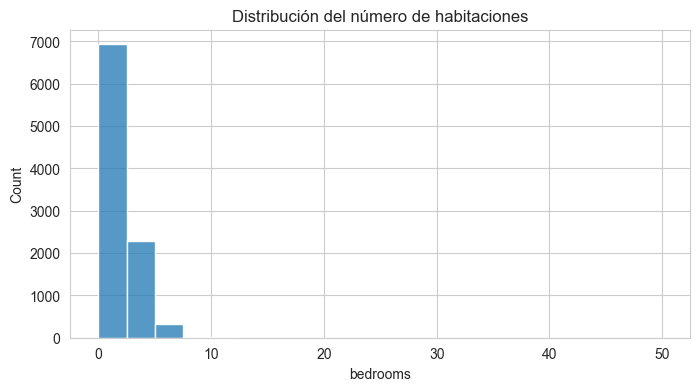

In [169]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["bedrooms"],
    bins=20
)

plt.title("Distribución del número de habitaciones")

plt.show()

La distribución del número de habitaciones presenta una clara concentración en alojamientos con una o dos habitaciones, mientras que los inmuebles con un mayor número de habitaciones son mucho menos frecuentes. Esta distribución refleja la composición general de la oferta disponible en StaySpain y servirá para contextualizar los análisis posteriores sobre capacidad y ocupación.

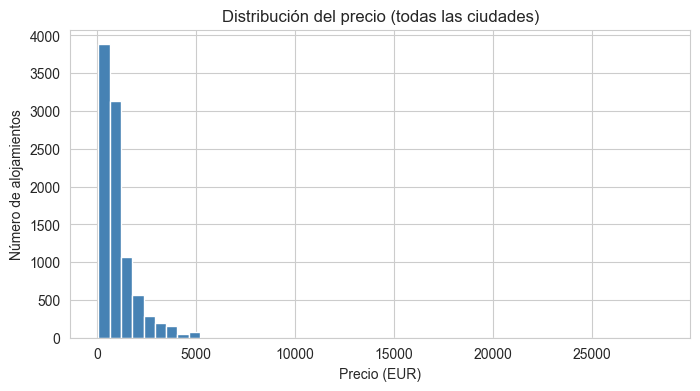

In [170]:
# Distribución del precio: histograma
# (price tiene nulos, se excluyen solo para este gráfico)
plt.figure(figsize=(8, 4))
plt.hist(df["price_€"].dropna(), bins=50, color="steelblue")
plt.title("Distribución del precio (todas las ciudades)")
plt.xlabel("Precio (EUR)")
plt.ylabel("Número de alojamientos")
plt.show()


El histograma muestra una fuerte asimetría a la derecha: la
mayoría de los precios se concentra en valores bajos/medios,
con una cola larga de alojamientos de precio muy alto (posibles
alojamientos de lujo o valores atípicos).


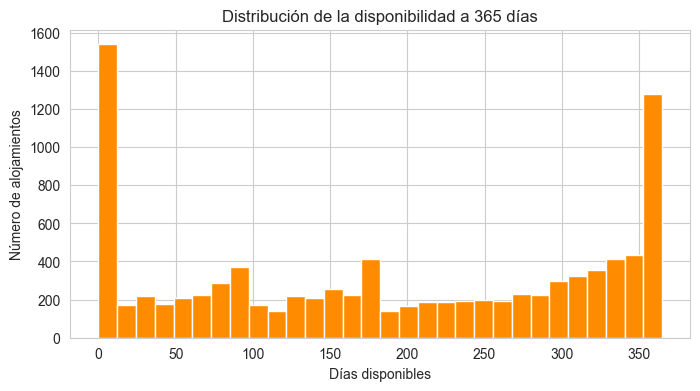

In [171]:
# Distribución de la disponibilidad a 365 días
plt.figure(figsize=(8, 4))
plt.hist(df["availability_365"].dropna(), bins=30, color="darkorange")
plt.title("Distribución de la disponibilidad a 365 días")
plt.xlabel("Días disponibles")
plt.ylabel("Número de alojamientos")
plt.show()


La disponibilidad a 365 días presenta una distribución amplia y no uniforme, con concentraciones en determinados niveles. Esta variable representa días publicados como disponibles y no debe interpretarse directamente como ocupación o demanda real.

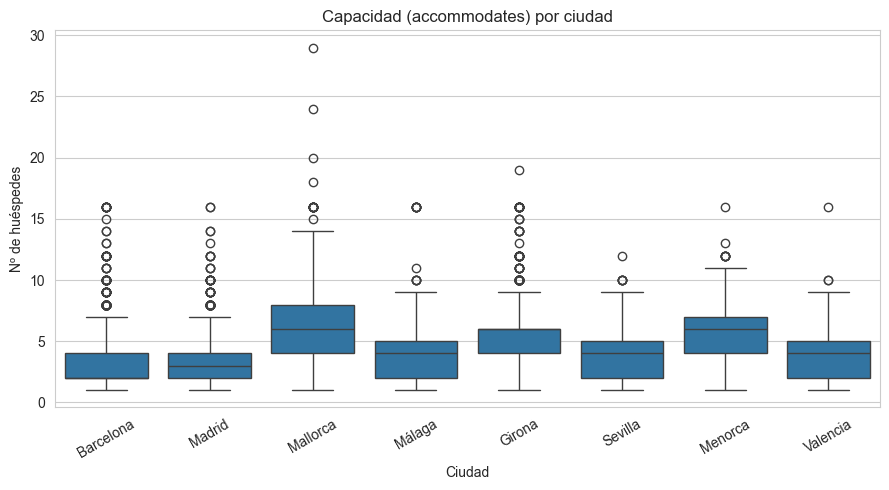

In [172]:
# Boxplot de accommodates por ciudad (capacidad)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="city", y="accommodates")
plt.title("Capacidad (accommodates) por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Nº de huéspedes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


La capacidad de los alojamientos varía entre ciudades y presenta valores extremos en algunos mercados. Las diferencias específicas se analizarán posteriormente en los notebooks de cada perfil.

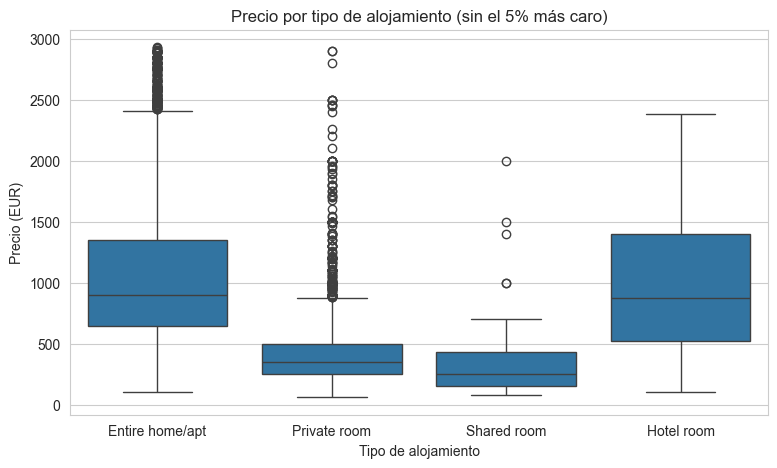

In [173]:
# Boxplot del precio por tipo de alojamiento
# (se excluye el 5% más caro solo para visualizar mejor)
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df[df["price_€"] < df["price_€"].quantile(0.95)],
    x="room_type", y="price_€",
)
plt.title("Precio por tipo de alojamiento (sin el 5% más caro)")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Precio (EUR)")
plt.show()


Los tipos de alojamiento muestran distribuciones de precio diferentes. Para mejorar la legibilidad del gráfico se excluye únicamente en la visualización el 5 % de precios más altos; estas observaciones permanecen en el dataset.

,city,precio_medio
0,Mallorca,1655.87
1,Menorca,1651.16
2,Girona,1200.62
3,Sevilla,943.56
4,Barcelona,830.15
5,Madrid,791.39
6,Málaga,746.04
7,Valencia,658.65


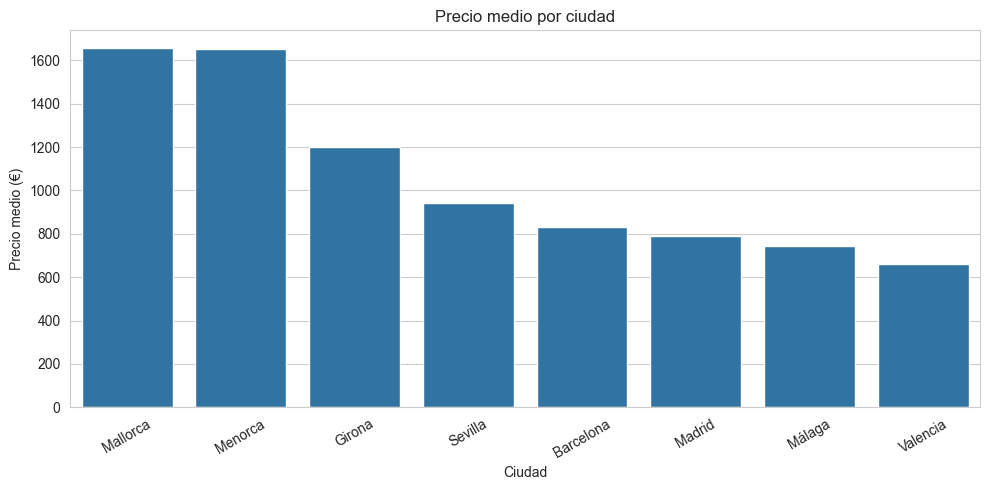

In [176]:
# Precio medio de los alojamientos por ciudad
# (calculado sobre los alojamientos disponibles en el dataset)
precio_ciudad = (
    df.groupby("city")
      .agg(precio_medio=("price_€", "mean"))
      .round(2)
      .sort_values("precio_medio", ascending=False)
      .reset_index()
)

display(precio_ciudad)

plt.figure(figsize=(10,5))

sns.barplot(
    data=precio_ciudad,
    x="city",
    y="precio_medio"
)

plt.title("Precio medio por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Precio medio (€)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

El precio medio presenta diferencias entre ciudades, reflejando distintos niveles de posicionamiento de la oferta. Estas diferencias se analizarán posteriormente junto con la demanda turística y la ocupación para valorar posibles estrategias de negocio.

In [ ]:
# calculamos occupancy_365

df["occupancy_365"] = ((365 - df["availability_365"]) / 365 * 100).round(2)

,city,ocupacion_media
0,madrid,54.88
1,valencia,53.28
2,barcelona,49.51
3,sevilla,46.36
4,girona,45.97
5,menorca,45.30
6,malaga,45.29
7,mallorca,41.24


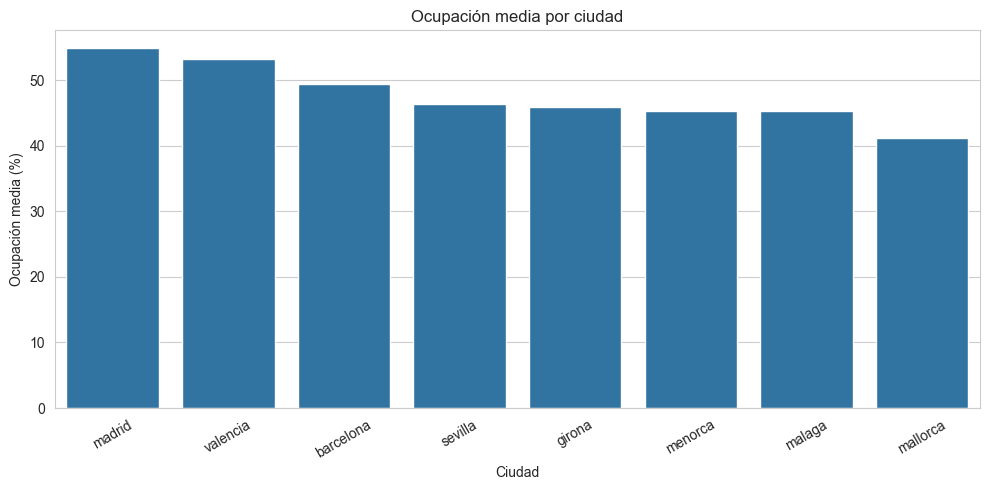

In [ ]:
# Ocupación media anual por ciudad
# (calculada a partir de occupancy_365)
ocupacion_ciudad = (
    df.groupby("city")
      .agg(ocupacion_media=("occupancy_365", "mean"))
      .round(2)
      .sort_values("ocupacion_media", ascending=False)
      .reset_index()
)

display(ocupacion_ciudad)

plt.figure(figsize=(10,5))

sns.barplot(
    data=ocupacion_ciudad,
    x="city",
    y="ocupacion_media"
)

plt.title("Ocupación media por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ocupación media (%)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

 La ocupación media permite comparar el grado de utilización de la oferta entre ciudades. Este indicador constituye una referencia clave para interpretar el comportamiento de los alojamientos y contrastarlo posteriormente con los datos oficiales de demanda turística publicados por la EOH.

## 5. Valoración de los alojamientos

In [ ]:
# Valoración media por ciudad
rating_ciudad = (
    df.groupby("city")
      .agg(
          rating_medio=("review_scores_rating", "mean")
      )
      .round(2)
      .sort_values("rating_medio", ascending=False)
      .reset_index()
)

rating_ciudad

,city,rating_medio
0,sevilla,936.37
1,menorca,934.43
2,mallorca,930.26
3,madrid,926.58
4,malaga,922.28
5,valencia,922.22
6,girona,909.68
7,barcelona,906.83


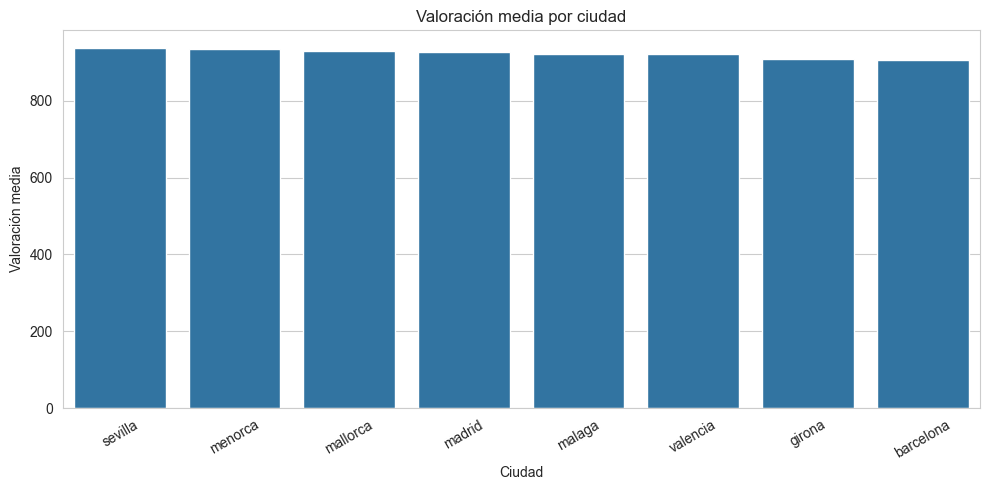

In [ ]:
# Gráfico de la valoración media por ciudad
plt.figure(figsize=(10, 5))

sns.barplot(
    data=rating_ciudad,
    x="city",
    y="rating_medio"
)

plt.title("Valoración media por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Valoración media")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()


La valoración media presenta niveles elevados en todas las ciudades, con diferencias relativamente pequeñas entre ellas. Este resultado sugiere una percepción general positiva de los alojamientos incluidos en StaySpain y proporciona una referencia para complementar el análisis de la oferta junto con el precio y la ocupación en las siguientes fases del proyecto.

## 6. Correlaciones exploratorias

Se mantienen como análisis separados porque tienen objetivos distintos:

- **Pearson** conserva una selección reducida de variables y permite revisar relaciones lineales de forma clara.

Las correlaciones son exploratorias y se calculan a nivel de registro sobre el dataset bruto validado. Para los análisis de negocio posteriores se utilizará un único registro por alojamiento, correspondiente al último `insert_date` disponible.

### Matriz de correlación de Pearson

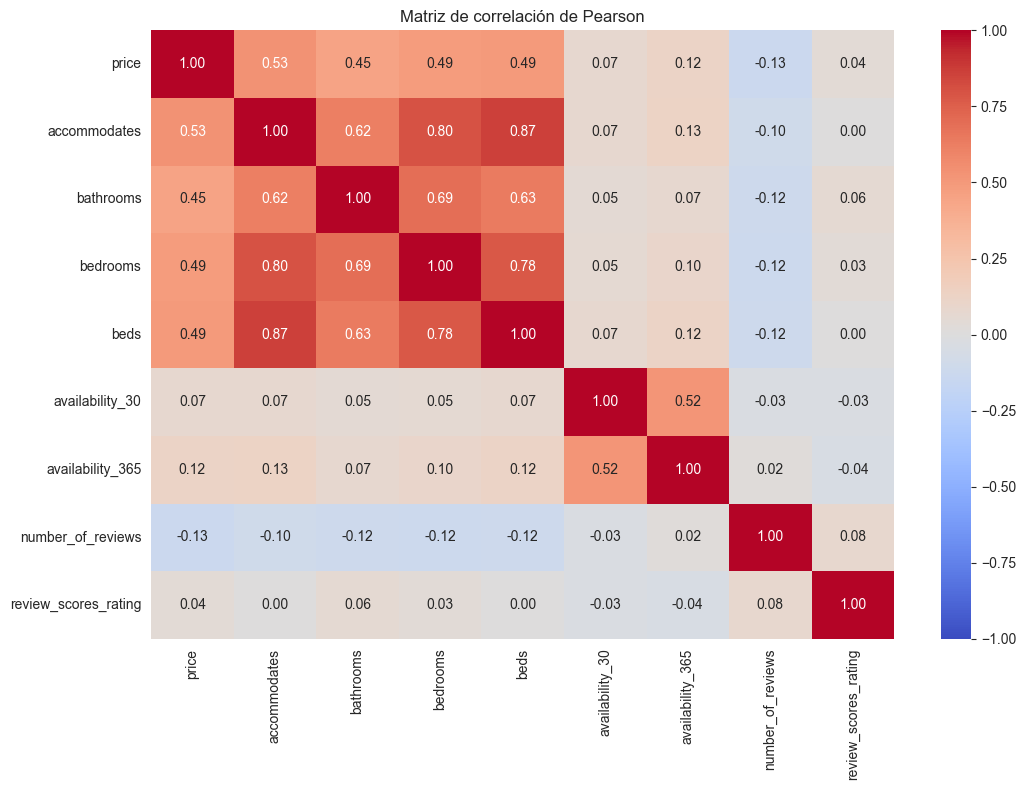

In [ ]:
# Pearson: selección reducida de variables numéricas relevantes
columnas_pearson = [
    "price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "availability_30",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
]

columnas_pearson = [
    columna
    for columna in columnas_pearson
    if columna in df.select_dtypes(include="number").columns
    and df[columna].nunique(dropna=True) > 1
]

matriz_pearson = df[columnas_pearson].corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    matriz_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

Pearson se mantiene con una selección pequeña de variables para facilitar la lectura de relaciones lineales y conservar la comparabilidad con la versión anterior del EDA.

## 7. Variables categóricas

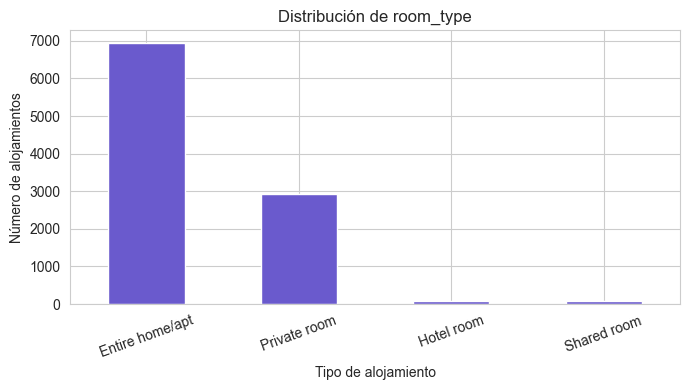

In [ ]:
plt.figure(figsize=(7, 4))
df["room_type"].value_counts().plot(kind="bar", color="slateblue")
plt.title("Distribución de room_type")
plt.xlabel("Tipo de alojamiento")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


La oferta de StaySpain está claramente dominada por los alojamientos de tipo **Entire home/apt**, que representan la mayor parte del catálogo disponible. En segundo lugar se sitúan las habitaciones privadas, mientras que las habitaciones de hotel y compartidas tienen una presencia residual. Estos resultados muestran que la plataforma se orienta principalmente al alquiler de alojamientos completos frente a otras modalidades.

9. Resumen por ciudad

In [ ]:
# Resumen de los principales indicadores por ciudad
resumen_ciudad = (
    df.groupby("city")
    .agg(
        alojamientos=("apartment_id", "nunique"),
        precio_medio=("price", "mean"),
        ocupacion_media=("occupancy_365", "mean"),
        rating_medio=("review_scores_rating", "mean"),
    )
    .round(2)
    .sort_values("alojamientos", ascending=False)
    .reset_index()
)

display(resumen_ciudad)

,city,alojamientos,precio_medio,ocupacion_media,rating_medio
0,barcelona,2719,830.31,49.51,906.83
1,madrid,2134,793.64,54.88,926.58
2,mallorca,1583,1654.59,41.24,930.26
3,girona,1485,1206.61,45.97,909.68
4,valencia,513,656.94,53.28,922.22
5,malaga,504,744.93,45.29,922.28
6,sevilla,494,955.62,46.36,936.37
7,menorca,218,1646.15,45.30,934.43


La comparación entre ciudades muestra diferencias relevantes en el tamaño y las características de la oferta. Barcelona concentra el mayor número de alojamientos, seguida de Madrid y Mallorca, mientras que Menorca presenta la menor oferta del conjunto analizado. También se observan variaciones en el precio medio y en la ocupación media, lo que indica que cada mercado presenta un comportamiento diferenciado. En cambio, las valoraciones medias son elevadas y bastante homogéneas entre todas las ciudades, con diferencias poco pronunciadas.

## 8. Conclusiones y próximos pasos

- El dataset analizado contiene 10.000 registros y 35 variables. La validación estructural no detecta incoherencias en las columnas numéricas esperadas, por lo que todas las observaciones se mantienen para el análisis exploratorio.

- Los `apartment_id` repetidos corresponden a snapshots temporales del mismo alojamiento y no a duplicados exactos. En los análisis posteriores se utilizará el registro más reciente de cada alojamiento para evitar contabilizar un mismo anuncio varias veces.

- `neighbourhood_district` es la variable con mayor proporción de valores nulos, mientras que las puntuaciones de las reseñas presentan una cobertura incompleta que deberá tenerse en cuenta en los análisis posteriores.

- La oferta de StaySpain se concentra en un reducido número de ciudades y está compuesta principalmente por alojamientos de tipo **Entire home/apt**, definiendo el perfil predominante de la plataforma.

- Se observan diferencias entre ciudades tanto en el precio medio como en la ocupación media, reflejando distintos niveles de posicionamiento y utilización de la oferta.

- La mayoría de los alojamientos dispone de una o dos habitaciones y las valoraciones medias son elevadas en todas las ciudades analizadas, con diferencias relativamente pequeñas entre ellas.

- La matriz de correlación de Pearson permite identificar relaciones lineales entre las principales variables numéricas y servirá como referencia para los análisis específicos de cada perfil.

- El resumen por ciudad proporciona una visión agregada de la oferta de StaySpain y constituye la base para compararla posteriormente con los indicadores de demanda turística procedentes de la Encuesta de Ocupación Hotelera (EOH).